<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week5/Day1/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Construire votre premier réseau neuronal sur le jeu de données MNIST


--- Étape 1 : Chargement et Prétraitement des Données ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Taille de l'ensemble d'entraînement : (60000, 28, 28)
Taille de l'ensemble de test         : (10000, 28, 28)


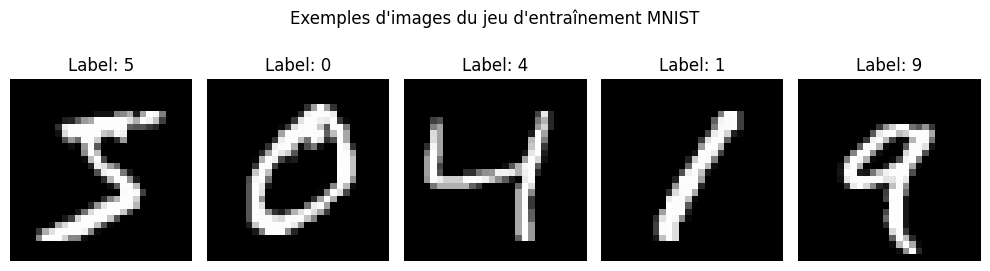


--- Étape 2 : Construction de l'Architecture Multi-Couches ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Étape 3 : Pipeline d'Entraînement (10 Époques) ---
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9178 - loss: 0.2870 - val_accuracy: 0.9653 - val_loss: 0.1169
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9659 - loss: 0.1142 - val_accuracy: 0.9728 - val_loss: 0.0845
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9751 - loss: 0.0808 - val_accuracy: 0.9750 - val_loss: 0.0828
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9816 - loss: 0.0601 - val_accuracy: 0.9773 - val_loss: 0.0744
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9853 - loss: 0.0469 - val_accuracy: 0.9778 - val_loss: 0.0807
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9890 - loss: 0.0360 - val_accuracy: 0.9762 - val_loss: 0.0905
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9906 - loss: 0.0291 - val_accuracy: 0.9785 - val_loss: 0.0798
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/

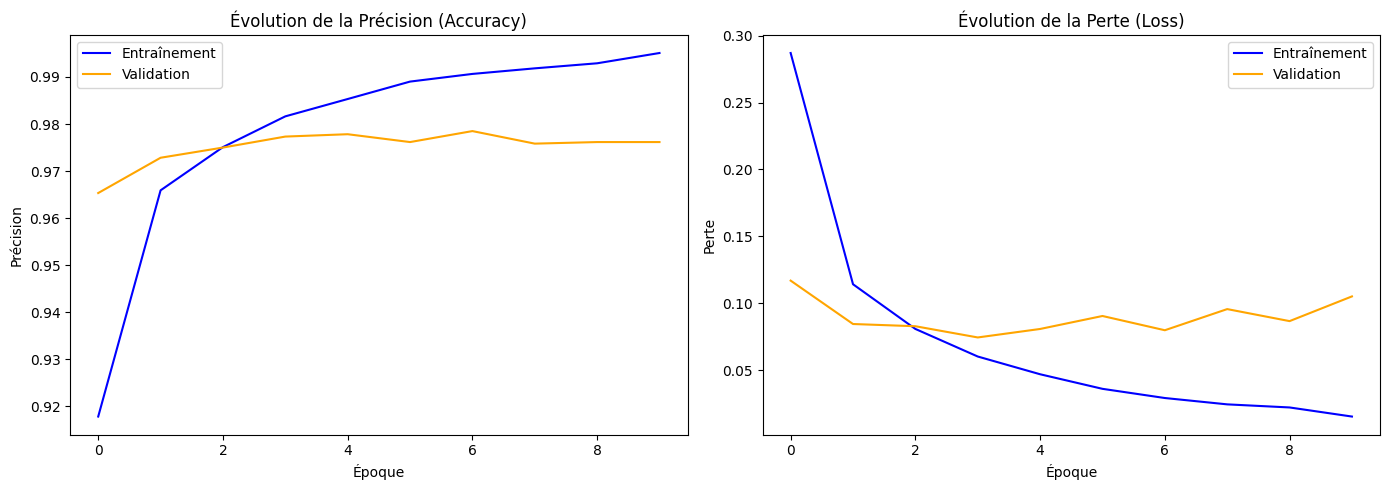


--- Étape 4 : Évaluation et Analyse des Erreurs ---
Précision finale sur l'ensemble de test (Accuracy) : 97.58 %
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


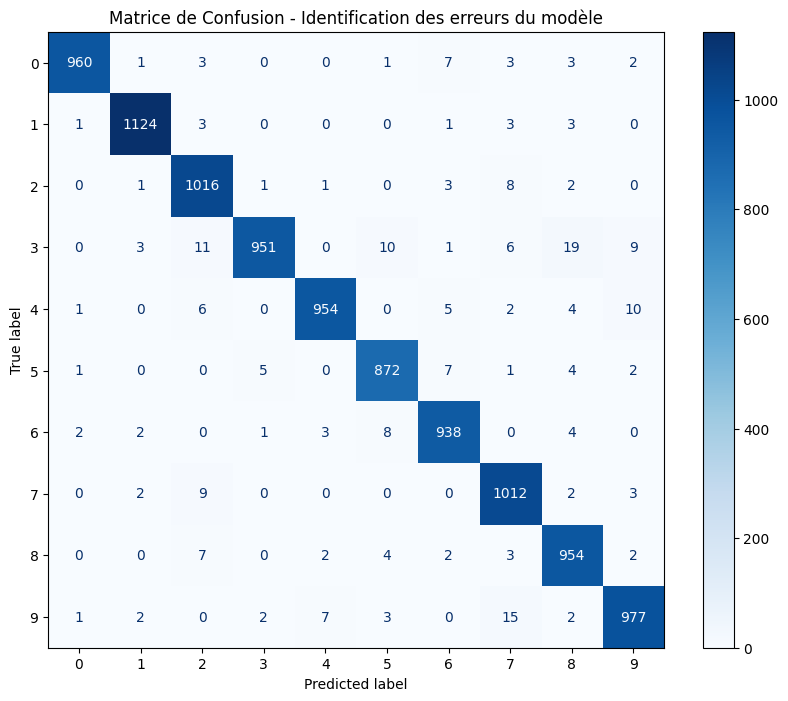


--- Diagnostic des faiblesses du modèle ---
👉 Le chiffre avec lequel le modèle a le plus de difficultés est le : 3
   (Il a été confondu 59 fois avec d'autres chiffres de la grille).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =====================================================================
# 1. CHARGER ET PRÉTRAITER L'ENSEMBLE DE DONNÉES MNIST
# =====================================================================
print("--- Étape 1 : Chargement et Prétraitement des Données ---")

# Chargement du jeu de données MNIST intégré à Keras
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalisation des valeurs de pixels (de [0, 255] à) pour stabiliser l'optimisation
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Conversion des étiquettes (0 à 9) au format encodé one-hot
y_train_oh = to_categorical(y_train, num_classes=10)
y_test_oh  = to_categorical(y_test, num_classes=10)

print(f"Taille de l'ensemble d'entraînement : {x_train.shape}")
print(f"Taille de l'ensemble de test         : {x_test.shape}")

# Affichage visuel de quelques exemples d'images avec leurs étiquettes
plt.figure(figsize=(10, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Exemples d'images du jeu d'entraînement MNIST")
plt.tight_layout()
plt.show()

# =====================================================================
# 2. CONSTRUIRE LE RÉSEAU NEURONAL ENTIÈREMENT CONNECTÉ
# =====================================================================
print("\n--- Étape 2 : Construction de l'Architecture Multi-Couches ---")

# Définition d'un modèle séquentiel
model = models.Sequential([
    # Aplatir les images d'entrée de 28x28 en un vecteur unidimensionnel de 784 valeurs
    layers.Flatten(input_shape=(28, 28)),

    # Première couche cachée : 128 neurones avec activation ReLU
    layers.Dense(128, activation='relu'),

    # Deuxième couche cachée : 64 neurones avec activation ReLU
    layers.Dense(64, activation='relu'),

    # Couche de sortie : 10 neurones (un par chiffre) avec activation Softmax pour les probabilités
    layers.Dense(10, activation='softmax')
])

# Compilation du modèle
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# =====================================================================
# 3. ENTRAÎNER LE RÉSEAU NEURONAL
# =====================================================================
print("\n--- Étape 3 : Pipeline d'Entraînement (10 Époques) ---")

# Ajustement du modèle avec 10 époques et une séparation de validation à 10%
history = model.fit(
    x_train, y_train_oh,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Visualisation des tendances de l'entraînement
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Graphique de la précision (Accuracy)
ax1.plot(history.history['accuracy'], label='Entraînement', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation', color='orange')
ax1.set_title("Évolution de la Précision (Accuracy)")
ax1.set_xlabel("Époque")
ax1.set_ylabel("Précision")
ax1.legend()

# Graphique de la perte (Loss)
ax2.plot(history.history['loss'], label='Entraînement', color='blue')
ax2.plot(history.history['val_loss'], label='Validation', color='orange')
ax2.set_title("Évolution de la Perte (Loss)")
ax2.set_xlabel("Époque")
ax2.set_ylabel("Perte")
ax2.legend()

plt.tight_layout()
plt.show()

# =====================================================================
# 4. ÉVALUER LES PERFORMANCES ET MATRICE DE CONFUSION
# =====================================================================
print("\n--- Étape 4 : Évaluation et Analyse des Erreurs ---")

# Calcul de la précision finale sur les données de test non vues
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
print("="*60)
print(f"Précision finale sur l'ensemble de test (Accuracy) : {test_acc*100:.2f} %")
print("="*60)

# Obtenir les prédictions du modèle pour la matrice de confusion
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Génération et affichage de la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title("Matrice de Confusion - Identification des erreurs du modèle")
plt.show()

# Identification automatique des chiffres posant le plus de difficultés
print("\n--- Diagnostic des faiblesses du modèle ---")
np.fill_diagonal(cm, 0) # On ignore les bonnes réponses pour isoler uniquement les erreurs
row_sums = cm.sum(axis=1)
worst_digit = np.argmax(row_sums)
print(f" Le chiffre avec lequel le modèle a le plus de difficultés est le : {worst_digit}")
print(f"   (Il a été confondu {row_sums[worst_digit]} fois avec d'autres chiffres de la grille).")
